In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 量化推理

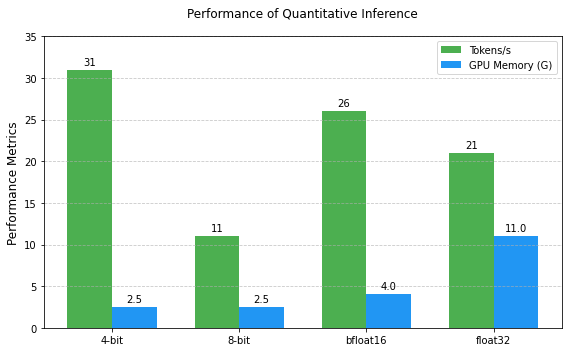

In [39]:
items = ["4-bit", "8-bit", "bfloat16", "float32"]
tokens_speeds = [31, 11, 26, 21]
gpu_memory = [2.5, 2.5, 4, 11]
precision = [0.793, 0.816, 0.864, 0.871]

x = np.arange(len(items))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

rects1 = ax.bar(x - width / 2, tokens_speeds, width, label="Tokens/s", color="#4CAF50")
rects2 = ax.bar(x + width / 2, gpu_memory, width, label="GPU Memory (G)", color="#2196F3")

ax.set_ylabel("Performance Metrics", fontsize=12)
ax.set_title("Performance of Quantitative Inference", pad=20)
ax.set_xticks(x)
ax.set_xticklabels(items)
ax.legend()


# 添加数值标签
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(
            f"{height}",
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 3),  # 3 points vertical offset
            textcoords="offset points",
            ha="center",
            va="bottom",
        )


add_labels(rects1)
add_labels(rects2)

plt.ylim(0, 35)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

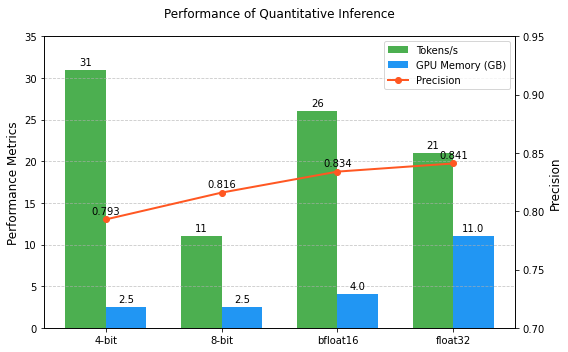

In [46]:
import numpy as np
import matplotlib.pyplot as plt

items = ["4-bit", "8-bit", "bfloat16", "float32"]
tokens_speeds = [31, 11, 26, 21]
gpu_memory = [2.5, 2.5, 4, 11]
precision = [0.793, 0.816, 0.834, 0.841]

x = np.arange(len(items))
width = 0.35

# 创建主画布和坐标轴
fig, ax = plt.subplots(figsize=(8, 5))
# 创建第二个Y轴
ax2 = ax.twinx()

# 绘制前两组柱状图（左侧Y轴）
rects1 = ax.bar(x - width / 2, tokens_speeds, width, label="Tokens/s", color="#4CAF50")
rects2 = ax.bar(
    x + width / 2, gpu_memory, width, label="GPU Memory (GB)", color="#2196F3"
)

# 绘制折线图（右侧Y轴）
(line,) = ax2.plot(
    x, precision, color="#FF5722", marker="o", label="Precision", linewidth=2
)

# 主Y轴设置
ax.set_ylabel("Performance Metrics", fontsize=12)
ax.set_title("Performance of Quantitative Inference", pad=20)
ax.set_xticks(x)
ax.set_xticklabels(items)
ax.set_ylim(0, 35)
ax.grid(axis="y", linestyle="--", alpha=0.7)

# 次Y轴设置
ax2.set_ylabel("Precision", fontsize=12)
ax2.set_ylim(0.7, 0.95)  # 根据数据范围调整

# 合并图例
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc="upper right")


# 添加柱状图数值标签
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(
            f"{height}",
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
        )


# 添加折线图数值标签
for i, val in enumerate(precision):
    ax2.annotate(
        f"{val:.3f}",
        xy=(x[i], val),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
    )

add_labels(rects1)
add_labels(rects2)

plt.tight_layout()
plt.show()

# KV Cache

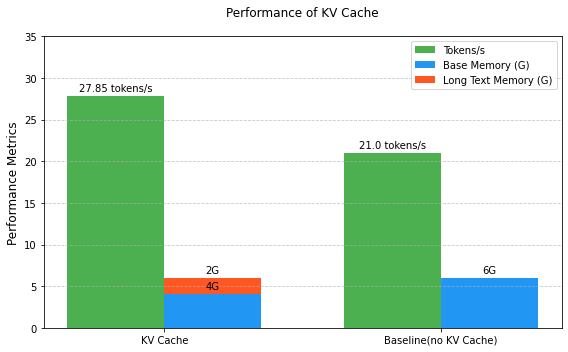

In [14]:
import matplotlib.pyplot as plt
import numpy as np

items = ["KV Cache", "Baseline(no KV Cache)"]
tokens_speeds = [27.85, 21]
gpu_memory_base = [4, 6]  # 基础显存
gpu_memory_add = [2, 0]  # 新增显存

x = np.arange(len(items))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

# 绘制Tokens/s柱状图
rects1 = ax.bar(x - width / 2, tokens_speeds, width, label="Tokens/s", color="#4CAF50")

# 绘制叠加的GPU Memory柱状图
rects2_base = ax.bar(
    x + width / 2, gpu_memory_base, width, label="Base Memory (G)", color="#2196F3"
)
rects2_add = ax.bar(
    x + width / 2,
    gpu_memory_add,
    width,
    bottom=gpu_memory_base,
    label="Long Text Memory (G)",
    color="#FF5722",
)

ax.set_ylabel("Performance Metrics", fontsize=12)
ax.set_title("Performance of KV Cache", pad=20)
ax.set_xticks(x)
ax.set_xticklabels(items)
ax.legend()


# 自定义标签添加函数
def add_labels(rects, unit=""):
    for rect in rects:
        height = rect.get_height()
        if height > 0:  # 仅对有效高度添加标签
            ax.annotate(
                f"{height}{unit}",
                xy=(
                    rect.get_x() + rect.get_width() / 2,
                    rect.get_y() + height if rect.get_y() else height,
                ),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
            )


# 添加不同标签
add_labels(rects1, " tokens/s")
add_labels(rects2_base, "G")
add_labels(rects2_add, "G")

# 添加总显存标签
total_memory = [b + a for b, a in zip(gpu_memory_base, gpu_memory_add)]
# for i, total in enumerate(total_memory):
#     if total > gpu_memory_base[i]:  # 仅对KV Cache添加总标签
#         ax.text(
#             x[i] + width / 2,
#             total + 1,
#             f"Total: {total}G",
#             ha="center",
#             va="bottom",
#             fontsize=9,
#         )

plt.ylim(0, 35)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# vllm

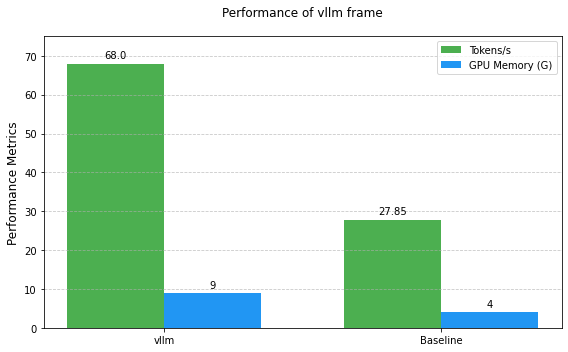

In [18]:
items = ["vllm", "Baseline"]
tokens_speeds = [68, 27.85]
gpu_memory = [9, 4]

x = np.arange(len(items))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

rects1 = ax.bar(x - width / 2, tokens_speeds, width, label="Tokens/s", color="#4CAF50")
rects2 = ax.bar(
    x + width / 2, gpu_memory, width, label="GPU Memory (G)", color="#2196F3"
)

ax.set_ylabel("Performance Metrics", fontsize=12)
ax.set_title("Performance of vllm frame", pad=20)
ax.set_xticks(x)
ax.set_xticklabels(items)
ax.legend()


# 添加数值标签
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(
            f"{height}",
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 3),  # 3 points vertical offset
            textcoords="offset points",
            ha="center",
            va="bottom",
        )

add_labels(rects1)
add_labels(rects2)

plt.ylim(0, 75)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# lora

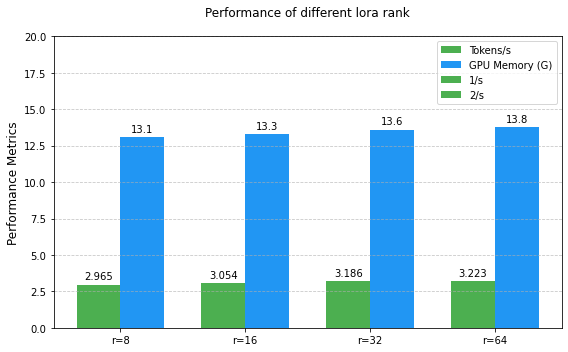

In [25]:
items = ["r=8", "r=16", "r=32", "r=64"]
tokens_speeds = [2.965, 3.054, 3.186, 3.223]
gpu_memory = [13.1, 13.3, 13.6, 13.8]
precision = [0.8278, 0.8414, 0.8526, 0.8712]
f1_scores = [0.828, 0.846, 0.837, 0.881]


x = np.arange(len(items))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

rects1 = ax.bar(x - width / 2, tokens_speeds, width, label="Tokens/s", color="#4CAF50")
rects2 = ax.bar(
    x + width / 2, gpu_memory, width, label="GPU Memory (G)", color="#2196F3"
)

ax.set_ylabel("Performance Metrics", fontsize=12)
ax.set_title("Performance of different lora rank", pad=20)
ax.set_xticks(x)
ax.set_xticklabels(items)
ax.legend()


# 添加数值标签
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(
            f"{height}",
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 3),  # 3 points vertical offset
            textcoords="offset points",
            ha="center",
            va="bottom",
        )


add_labels(rects1)
add_labels(rects2)

plt.ylim(0, 20)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

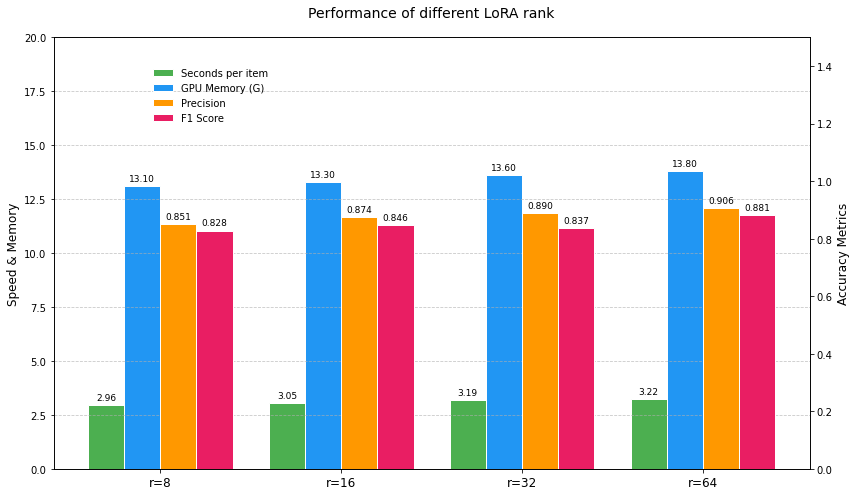

In [50]:
import matplotlib.pyplot as plt
import numpy as np

items = ["r=8", "r=16", "r=32", "r=64"]
tokens_speeds = [2.965, 3.054, 3.186, 3.223]
gpu_memory = [13.1, 13.3, 13.6, 13.8]
precision = [0.8512, 0.8743, 0.8896, 0.9061]
f1_scores = [0.828, 0.846, 0.837, 0.881]

# 创建画布和双轴系统
fig, ax1 = plt.subplots(figsize=(12, 7))
ax2 = ax1.twinx()

x = np.arange(len(items))  # 基础定位点 [0,1,2,3]
width = 0.2  # 调整后的单柱宽度

# 绘制四组柱状图（保持原代码结构）
rects1 = ax1.bar(
    x - width * 1.5,
    tokens_speeds,
    width,
    label="Seconds per item",
    color="#4CAF50",
    edgecolor="white",
)
rects2 = ax1.bar(
    x - width * 0.5,
    gpu_memory,
    width,
    label="GPU Memory (G)",
    color="#2196F3",
    edgecolor="white",
)
rects3 = ax2.bar(
    x + width * 0.5,
    precision,
    width,
    label="Precision",
    color="#FF9800",
    edgecolor="white",
)
rects4 = ax2.bar(
    x + width * 1.5,
    f1_scores,
    width,
    label="F1 Score",
    color="#E91E63",
    edgecolor="white",
)

# 保持原格式的坐标轴设置
ax1.set_ylabel("Speed & Memory", fontsize=12)
ax2.set_ylabel("Accuracy Metrics", fontsize=12)
ax1.set_title("Performance of different LoRA rank", pad=20, fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(items, fontsize=12)

# 保持原格式的网格线
ax1.grid(axis="y", linestyle="--", alpha=0.7)

# 调整坐标轴范围保持比例
ax1.set_ylim(0, 20)  # 原代码范围
ax2.set_ylim(0, 1.5)  # 新增精度指标范围

# 合并图例（保持原位置）
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left",
    bbox_to_anchor=(0.12, 0.95),
    frameon=False,
)


# 保持原格式的数值标签函数
def add_labels(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(
            f"{height:.3f}" if height < 1 else f"{height:.2f}",
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )


# 为所有柱子添加标签
add_labels(rects1, ax1)
add_labels(rects2, ax1)
add_labels(rects3, ax2)
add_labels(rects4, ax2)

plt.tight_layout()
plt.show()

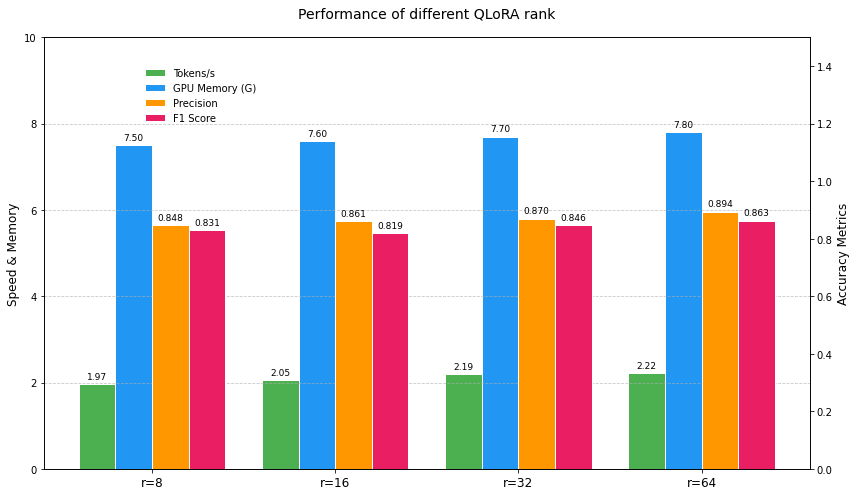

In [36]:
import matplotlib.pyplot as plt
import numpy as np

items = ["r=8", "r=16", "r=32", "r=64"]
tokens_speeds = [1.965, 2.054, 2.186, 2.223]
gpu_memory = [7.5, 7.6, 7.7, 7.8]
precision = [0.8481, 0.8613, 0.8698, 0.8941]
f1_scores = [0.831, 0.819, 0.846, 0.863]

# 创建画布和双轴系统
fig, ax1 = plt.subplots(figsize=(12, 7))
ax2 = ax1.twinx()

x = np.arange(len(items))  # 基础定位点 [0,1,2,3]
width = 0.2  # 调整后的单柱宽度

# 绘制四组柱状图（保持原代码结构）
rects1 = ax1.bar(
    x - width * 1.5,
    tokens_speeds,
    width,
    label="Seconds per item",
    color="#4CAF50",
    edgecolor="white",
)
rects2 = ax1.bar(
    x - width * 0.5,
    gpu_memory,
    width,
    label="GPU Memory (G)",
    color="#2196F3",
    edgecolor="white",
)
rects3 = ax2.bar(
    x + width * 0.5,
    precision,
    width,
    label="Precision",
    color="#FF9800",
    edgecolor="white",
)
rects4 = ax2.bar(
    x + width * 1.5,
    f1_scores,
    width,
    label="F1 Score",
    color="#E91E63",
    edgecolor="white",
)

# 保持原格式的坐标轴设置
ax1.set_ylabel("Speed & Memory", fontsize=12)
ax2.set_ylabel("Accuracy Metrics", fontsize=12)
ax1.set_title("Performance of different QLoRA rank", pad=20, fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(items, fontsize=12)

# 保持原格式的网格线
ax1.grid(axis="y", linestyle="--", alpha=0.7)

# 调整坐标轴范围保持比例
ax1.set_ylim(0, 10)  # 原代码范围
ax2.set_ylim(0, 1.5)  # 新增精度指标范围

# 合并图例（保持原位置）
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left",
    bbox_to_anchor=(0.12, 0.95),
    frameon=False,
)


# 保持原格式的数值标签函数
def add_labels(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(
            f"{height:.3f}" if height < 1 else f"{height:.2f}",
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )


# 为所有柱子添加标签
add_labels(rects1, ax1)
add_labels(rects2, ax1)
add_labels(rects3, ax2)
add_labels(rects4, ax2)

plt.tight_layout()
plt.show()